# package_LAB

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_LAB
import package_DBR
from package_DBR import SelectPath_RT
from package_LAB import LL_RT, PID_RT, IMC_Tuning

# LL_RT()

In [73]:
help(LL_RT)

Help on function LL_RT in module package_LAB:

LL_RT(MV, Kp, Tlead, Tlag, Ts, PV, PVInit=0, method='EBD')



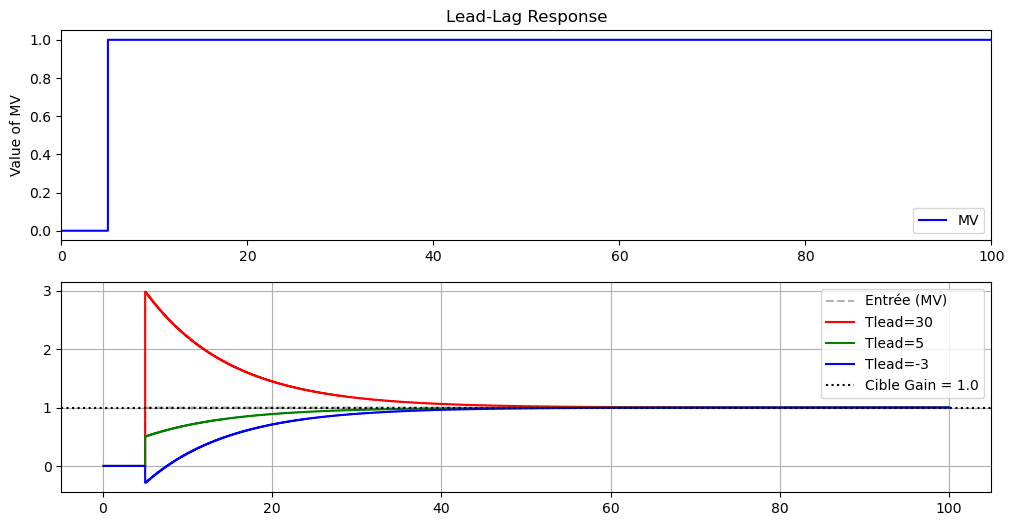

In [74]:
import numpy as np
import matplotlib.pyplot as plt


TSim = 100
Ts = 0.1 
N = int(TSim/Ts) + 1
t = []
MV = [] 
PV_lead = []; PV_lead2 = []; PV_lead3 = [] 

MVPath = {0: 0, 5: 1, TSim: 1}
Tlag_fixe = 10.0
Kp = 1.0


for i in range(1, N):
    t.append(i * Ts)
    SelectPath_RT(MVPath, t, MV)
    
    LL_RT(MV, Kp, 30.0, Tlag_fixe, Ts, PV_lead, method='EBD')
    LL_RT(MV, Kp, 5.0,  Tlag_fixe, Ts, PV_lead2, method='EBD')
    LL_RT(MV, Kp, -3.0, Tlag_fixe, Ts, PV_lead3, method='EBD')

plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.step(t,MV,'b-',label='MV',where='post')

plt.ylabel('Value of MV')
plt.title('Lead-Lag Response')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.subplot(2,1,2)
plt.step(t, MV, 'k--', label='Entrée (MV)', where='post', alpha=0.3)
plt.step(t, PV_lead, 'r-', label='Tlead=30 ', where='post')
plt.step(t, PV_lead2, 'g-', label='Tlead=5 ', where='post')
plt.step(t, PV_lead3, 'b-', label='Tlead=-3 ', where='post')
plt.axhline(y=Kp, color='k', linestyle=':', label='Cible Gain = 1.0')
plt.legend(); plt.grid(True); plt.show()

# PID_RT()

In [75]:
help(PID_RT)

Help on function PID_RT in module package_LAB:

PID_RT(
    SP,
    PV,
    Man,
    MVMan,
    MVFF,
    Kc,
    Ti,
    Td,
    alpha,
    Ts,
    MVMin,
    MVMax,
    MV,
    MVP,
    MVI,
    MVD,
    E,
    ManFF=False,
    PVInit=0,
    method='EBD'
)



In [76]:
Kp = 0.36
Tp1 = 170.82
Tp2 = 26.55
thetap = 13.31

Kd = 0.31
Td1 = 161.20
Td2 = 32.3
thetad = 15.75

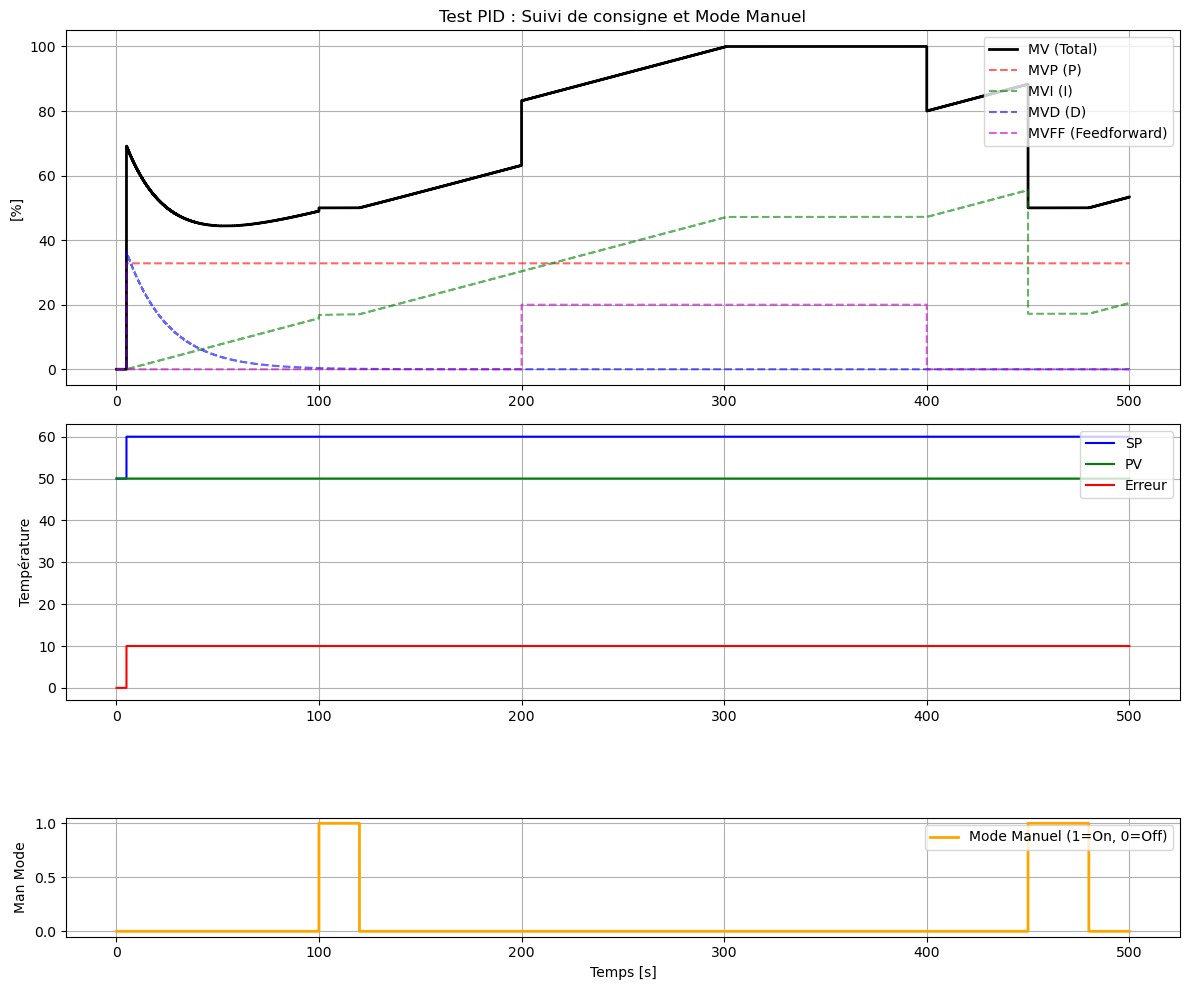

PID Tuning : Kc=3.28, Ti=197.37, Td=22.98
Dernières valeurs : P=32.82, I=20.52, D=0.00, FF=0.00


In [77]:
TSim = 500
Ts = 0.1 
N = int(TSim/Ts) + 1

t = []
E = []
SP = []
PV = []
Man = []
MVMan = []
MVFF = []
MV = []
MVP = [] 
MVI = [] 
MVD = []


SPPath = {0: 50, 5: 60, TSim: 60}
PVPath = {0: 50, TSim: 50}
ManPath = {0: False, 100: True, 120: False, 450: True,  480: False, TSim: False}
MVManPath = {0: 50, TSim: 50}
MVFFPath = {0: 0, 200: 20, 400:0, TSim: 0}

alpha = 0.9
Kc, Ti, Td = IMC_Tuning(Kp, Tp1, thetap, T2= Tp2, tauc=alpha*Tp1 , model='SOPDT')
MVMin = 0
MVMax = 100

for i in range(1, N):
    t.append(i * Ts)
    
    SelectPath_RT(SPPath, t, SP)
    SelectPath_RT(PVPath, t, PV)
    SelectPath_RT(ManPath, t, Man)
    SelectPath_RT(MVManPath, t, MVMan)
    SelectPath_RT(MVFFPath, t, MVFF)
    
    
    PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha, Ts, MVMin, MVMax, MV, MVP, MVI, MVD, E)



plt.figure(figsize=(12, 10))

#MV 
ax1 = plt.subplot2grid((12, 1), (0, 0), rowspan=5)
ax1.step(t, MV, 'k-', lw=2, label='MV (Total)', where='post')
ax1.step(t, MVP, 'r--', label='MVP (P)', where='post', alpha=0.6)
ax1.step(t, MVI, 'g--', label='MVI (I)', where='post', alpha=0.6)
ax1.step(t, MVD, 'b--', label='MVD (D)', where='post', alpha=0.6)
ax1.step(t, MVFF, 'm--', label='MVFF (Feedforward)', where='post', alpha=0.6)
ax1.set_ylabel('[%]')
ax1.set_title('Test PID : Suivi de consigne et Mode Manuel')
ax1.legend(loc='upper right')
ax1.grid(True)

#SP, PV et E 
ax2 = plt.subplot2grid((12, 1), (5, 0), rowspan=4)
ax2.step(t, SP, 'b-', label='SP', where='post')
ax2.step(t, PV, 'g-', label='PV', where='post')
ax2.step(t, E, 'r-', label='Erreur', where='post')
ax2.set_ylabel('Température')
ax2.legend(loc='upper right')
ax2.grid(True)

#Mode Manuel 
ax3 = plt.subplot2grid((12, 1), (10, 0), rowspan=2)
ax3.step(t, [int(m) for m in Man], 'orange', lw=2, label='Mode Manuel (1=On, 0=Off)', where='post')
ax3.set_ylabel('Man Mode')
ax3.set_xlabel('Temps [s]')
ax3.legend(loc='upper right')
ax3.grid(True)

plt.tight_layout()
plt.show()
print(f"PID Tuning : Kc={Kc:.2f}, Ti={Ti:.2f}, Td={Td:.2f}")
print(f"Dernières valeurs : P={MVP[-1]:.2f}, I={MVI[-1]:.2f}, D={MVD[-1]:.2f}, FF={MVFF[-1]:.2f}")